# Simulation

Simulation is the process of using a computer to mimic a physical experiment. In this class, those experiments will almost invariably involve chance.

We have seen how to simulate the results of tosses of a coin. The steps in that simulation were examples of the steps that will constitute every simulation we do in this course. In this section we will set out those steps and follow them in examples.

## The Process

**Step 1: What to Simulate**

Decide which quantity you want to simulate. For example, you might decide that you want to simulate the outcomes of tosses of a coin. Each simulated value will be a Head or a Tail.

**Step 2: Simulating One Value**

Figure out how to simulate *one* value of the quantity you specified in Step 1. Typically, we will define a function that returns the simulated value.

**Step 3: Number of Repetitions**

Decide how many times you want to simulate the quantity.

**Step 4: Simulating Multiple Values**

- Create an empty array in which to collect all the simulated values.
- Create a repetitions sequence, usually `np.arange(n)`.
- Use a `for` loop to repeatedly simulate one value and add it to the collection array.

Once complete, the collection array contains all simulated values and can be analyzed with NumPy, pandas, and visualization tools.

In [1]:
import pandas as pd
path_data = "../../../assets/data/"
import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
import numpy as np

## Example: Number of Heads in 100 Tosses

It is natural to expect that in 100 tosses of a coin there will be about 50 heads. In this example we will simulate the number of heads in 100 tosses and visualize the results.

**Step 1: What to Simulate**

The quantity we are going to simulate is the number of heads in 100 tosses.

**Step 2: Simulating One Value**

We start by creating a coin.

In [2]:
coin = np.array(['Heads', 'Tails'])

NumPy can simulate many coin tosses at once. Here are the results of 10 tosses.

In [3]:
ten_tosses = np.random.choice(coin, 10)
ten_tosses

array(['Heads', 'Tails', 'Heads', 'Heads', 'Heads', 'Tails', 'Tails',
       'Tails', 'Tails', 'Heads'], dtype='<U5')

We can count the number of heads using `np.count_nonzero`.

In [4]:
np.count_nonzero(ten_tosses == 'Heads')

np.int64(5)

To simulate 100 tosses, we simply change the number of draws.

In [5]:
outcomes = np.random.choice(coin, 100)
num_heads = np.count_nonzero(outcomes == 'Heads')
num_heads

np.int64(47)

Since we will do this many times, we define a function.

In [6]:
def one_simulated_value():
    outcomes = np.random.choice(coin, 100)
    return np.count_nonzero(outcomes == "Heads")

**Step 3: Number of Repetitions**

We will use 20,000 repetitions.

**Step 4: Simulating Multiple Values**

In [7]:
num_repetitions = 20000

heads = np.array([])

for i in np.arange(num_repetitions):
    new_value = one_simulated_value()
    heads = np.append(heads, new_value)

Check that the array contains 20,000 simulated values.

In [8]:
len(heads)

20000

To study the variability in the number of heads, place the results in a pandas DataFrame and draw a histogram.

In [9]:
simulation_results = pd.DataFrame({
    'Repetition': np.arange(1, num_repetitions + 1),
    'Number of Heads': heads
})
simulation_results.head(3)

,Repetition,Number of Heads
0,1,55.0
1,2,53.0
2,3,48.0


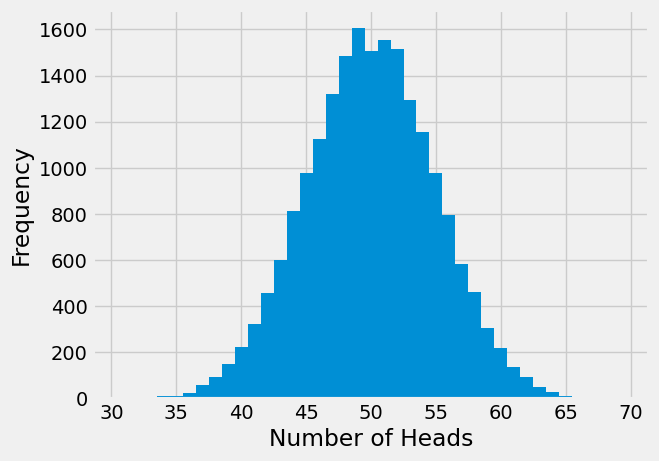

In [10]:
simulation_results['Number of Heads'].plot.hist(bins=np.arange(30.5, 69.6, 1))
plt.xlabel('Number of Heads')
plt.show()

Each bin has width 1 and is centered at a possible value of the number of heads. The histogram is roughly symmetric around 50 heads. Most repetitions produce between about 35 and 65 heads, with the bulk between about 45 and 55 heads.

Although the theoretical range is 0 to 100 heads, the simulation demonstrates that the range of likely values is much smaller.

## Example: Moves in Monopoly

Each move in Monopoly is determined by the total number of spots on two rolls of a die. We can explore this by simulating the sum of two rolls.

In [11]:
die = np.arange(1, 7)
sum(np.random.choice(die, 2))

np.int64(3)

We can use this idea to define a function that simulates one Monopoly move.

In [12]:
def one_simulated_move():
    return sum(np.random.choice(die, 2))

Now create an array of 10,000 simulated Monopoly moves.

In [13]:
num_repetitions = 10000

moves = np.array([])
for i in np.arange(num_repetitions):
    new_move = one_simulated_move()
    moves = np.append(moves, new_move)

Here is a histogram of the results.

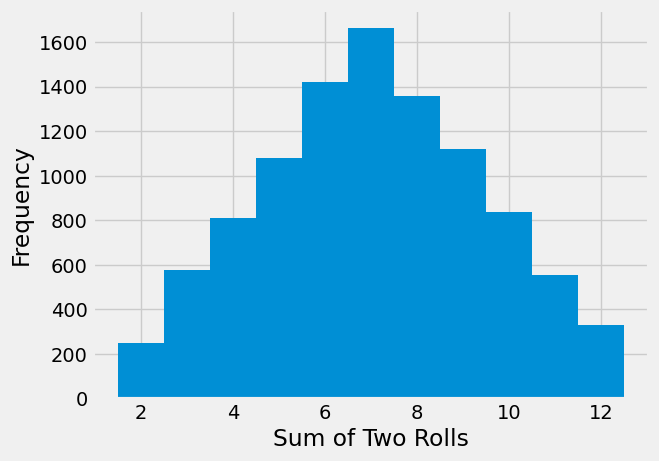

In [14]:
results = pd.DataFrame({
    'Repetition': np.arange(1, num_repetitions + 1),
    'Sum of Two Rolls': moves
})

results['Sum of Two Rolls'].plot.hist(bins=np.arange(1.5, 12.6, 1))
plt.xlabel('Sum of Two Rolls')
plt.show()

Seven is the most common value, with frequencies falling off symmetrically on either side.